Plotting the flux jacobian on the mesh to check if the pattern of the matrix make sense
- read the .mtx file by mmread()
- overlay the data on .vtk
- plot the scalar data on mesh surface

Read
- .plt file
- .mtx file (the global flux jacobian matrix)

In [13]:
from scipy.io import mmwrite, mmread
import pyvista as pv
import numpy as np
import pandas as pd
from pyau3d.utils import PltFileUtils, UnkFileUtils
from pyau3d.pv.loader.au3d import arrays2vtk

from scipy.sparse import save_npz, load_npz
from scipy.spatial import KDTree
pv.set_jupyter_backend('trame')


ImportError: Please install trame dependencies: pip install "pyvista[jupyter]"

In [5]:
def specific_energy(rho, p, ux, uy, uz, gamma=1.4):
    return p / ((gamma - 1.0) * rho) + 0.5 * (ux**2 + uy**2 + uz**2)

def conservative_variables(rst, GAMMA):
    """Return conservative variables U on the surface."""
    E = specific_energy(rst.rho, rst.p, rst.ux, rst.uy, rst.uz, GAMMA)

    U = np.column_stack((
        rst.rho,
        rst.rho * rst.ux,
        rst.rho * rst.uy,
        rst.rho * rst.uz,
        rst.rho * E
    ))
    return U

In [6]:
# build_boundary_list function

# Area normal function - helper function

def area_normals(coord, ifac3=None, ifac4=None):
    """
    Compute area-weighted normal vectors (Ax, Ay, Az) at each nodes,
    accumulated from triangle and/or quadrilateral faces. No PolyData is
    built; only the (N, 3) array is returned.
 
    For each face, the area-normal vector is:
        triangle : 0.5 * cross(v1 - v0, v2 - v0)
        quad     : sum of the two triangle area-normals from splitting
                   the quad (0,1,2) + (0,2,3)
    Each face's area-normal is split equally among its vertices and summed.

    That is how it accounted from the node-centered formulation
 
    Args:
        coord : (N, 3) array of mesh point coordinates
        ifac3 : (M3, 3) array of triangle connectivity, zero-based (or None)
        ifac4 : (M4, 4) array of quad connectivity, zero-based (or None)
 
    Returns:
        anor : (N, 3) array of area-weighted normals (Ax, Ay, Az) per point
    """
    coord = np.asarray(coord, dtype=float)
    anor = np.zeros_like(coord)
 
    if ifac3 is not None and len(ifac3) > 0:
        ifac3 = np.asarray(ifac3)
        v0, v1, v2 = coord[ifac3[:, 0]], coord[ifac3[:, 1]], coord[ifac3[:, 2]]
        face_anor = 0.5 * np.cross(v1 - v0, v2 - v0)   # (M3, 3)
        contrib = -face_anor / 3.0                      # sign matches ref code
        for k in range(3):
            np.add.at(anor, ifac3[:, k], contrib)
 
    if ifac4 is not None and len(ifac4) > 0:
        ifac4 = np.asarray(ifac4)
        v0, v1, v2, v3 = (coord[ifac4[:, 0]], coord[ifac4[:, 1]],
                          coord[ifac4[:, 2]], coord[ifac4[:, 3]])
        n1 = 0.5 * np.cross(v1 - v0, v2 - v0)
        n2 = 0.5 * np.cross(v2 - v0, v3 - v0)
        face_anor = n1 + n2                              # (M4, 3)
        contrib = -face_anor / 4.0
        for k in range(4):
            np.add.at(anor, ifac4[:, k], contrib)
 
    return anor


def boundary_geometry(pltfile, coord, fortfile, flag):
    """
    Wall-normal distance for each boundary node on a given surface.

    ds_i = mean over interior neighbours j of | n_hat_i . (x_j - x_i) |

    Returns
    -------
    (Nb, 5) array: [node_id (0-based), Abx, Aby, Abz, ds]

    """
    # use extract_surface_real to ifac4 as well 
    surface_nodes, tri_connect, quad_connect = pltfile.extract_surface_real(flag = flag)

    # get surface coordinates (0 based indexing)
    surface_coord = coord[surface_nodes]

    surface_area_normals = area_normals(surface_coord, ifac3=tri_connect, ifac4 = quad_connect)

    n_hat = surface_area_normals / np.linalg.norm(surface_area_normals, axis=1, keepdims=True)

    # global node id -> row in surface_nodes / n_hat
    local_index = -np.ones(coord.shape[0], dtype=int)
    local_index[surface_nodes] = np.arange(len(surface_nodes))

    surface_mask = np.zeros(coord.shape[0], dtype=bool)
    surface_mask[surface_nodes] = True

    ds_lists = {}   # boundary node id -> list of projected distances to its interior neighbours

    for row in fortfile:
        a = int(row[0]) - 1   # 0-based
        b = int(row[1]) - 1

        a_surf = surface_mask[a]
        b_surf = surface_mask[b]

        if a_surf and not b_surf:
            node, neigh = a, b
        elif b_surf and not a_surf:
            node, neigh = b, a
        else:
            continue   # both on surface (tangential edge) or both interior -> not what we want

        normal = n_hat[local_index[node]]
        vec = coord[neigh] - coord[node]
        ds_proj = abs(np.dot(vec, normal))

        ds_lists.setdefault(node, []).append(ds_proj)

    node_ids = np.array(sorted(ds_lists.keys()))
    ds = np.array([np.mean(ds_lists[n]) for n in node_ids])

    return np.column_stack([node_ids, surface_area_normals, ds])


def build_boundary_list(pltfile, coord, fortfile, flags_bc_map):
    """
    boundary_list : (B, 12) ndarray
        col 0    : node i (1-based)
        col 1-3  : [Ax, Ay, Az]  outward area-weighted normal
        col 4    : ds
        col 5    : bc_type   0=riemann | 1=slip | 2=noslip
        col 6-8  : u_b, v_b, w_b
        col 9    : T_b
        col 10   : P_b
        col 11   : flag (surface id, for filtering/debugging)
    """
    rows = []
    for flag, bc in flags_bc_map.items():
        geom = boundary_geometry(pltfile, coord, fortfile, flag)
        n = geom.shape[0]
        bc_cols = np.tile([
            float(bc['bc_type']), float(bc['u_b']), float(bc['v_b']),
            float(bc['w_b']), float(bc['T_b']), float(bc['P_b']),
        ], (n, 1))
        node_1based = geom[:, [0]] + 1.0
        flag_col = np.full((n, 1), flag, dtype=float)
        rows.append(np.hstack([node_1based, geom[:, 1:5], bc_cols, flag_col]))
        
    return np.vstack(rows)

In [18]:
# 1. Read neccessary files
Mesh = 540156
Re   = 60
Mach = 0.73
gamma = 1.4
R_gas = 287.0          # confirm units match the solver
mesh_ver = 3
case_name = "OAT"

# dir = f"C:/Users/User/Git/flux_jacobian/cases/cylinder_{Mesh}_Re{Re}_M{Mach}"
# dir = f"/home/ahf25/CFD_2d_cylinder_all/Steady/Ma{Mach}/v{mesh_ver}_mesh/2d_cylinder_{Mesh}_Re{Re}" 

dir = f"/home/ahf25/OAT15/OAT15_M0.73_A35" 
pltfile = PltFileUtils(f"{dir}/{case_name}.plt")
rstfile = UnkFileUtils(f"{dir}/{case_name}.unk", extend=False)  # both rst and unk are fine

fortfile = pd.read_csv(f"{dir}/fort.864", sep=r'\s+', header=None).to_numpy()

rstfile._primitive()
U_list = conservative_variables(rstfile, gamma)
coord  = pltfile.coord

# # Read the jacobians from ./data
# data_dir = f"/home/ahf25/git/flux_jacobian/data/flux_jacobian_assembly_v4/v{mesh_ver}_mesh"
# # data_dir = "C:/Users/User/Git/flux_jacobian/data/flux_jacobian_assembly_v4"
# npz_file = f"jacobian_cylinder_{Mesh}_Re{Re}_M{Mach}_fd.npz"

data_dir = f"/home/ahf25/git/flux_jacobian/data/flux_jacobian_assembly_v5"
npz_file = "jacobian_OAT15_M0.73_A35_fd.npz"

global_flux_jacobian_fd = load_npz(f"{data_dir}/{npz_file}")

In [9]:
# rebuild boundary list

# u_in  = 68.0525;  v_in  = 0.0;  w_in  = 0.0
# T_in  = 288.15;   P_in  = 1.32702
# u_out = 68.0525;  v_out = 0.0;  w_out = 0.0
# T_out = 288.15;   P_out = 1.32702

# flags_bc_map = {
#     1: {'bc_type': 0, 'u_b': u_in,  'v_b': v_in,  'w_b': w_in,  'T_b': T_in,  'P_b': P_in},
#     2: {'bc_type': 0, 'u_b': u_out, 'v_b': v_out, 'w_b': w_out, 'T_b': T_out, 'P_b': P_out},
#     3: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
#     4: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
#     5: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
#     6: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
#     7: {'bc_type': 2, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
# }


# for OAT15 M=0.73, AoA = 18569

u_in  = 252.98;  v_in  = 0.0;  w_in  = 15.47
T_in  = 300;   P_in  = 18569
u_out = 252.98;  v_out = 0.0;  w_out = 15.47
T_out = 300;   P_out = 18569

# bc_type   0=riemann | 1=slip | 2=noslip
flags_bc_map = {
    1: {'bc_type': 0, 'u_b': u_in,  'v_b': v_in,  'w_b': w_in,  'T_b': T_in,  'P_b': P_in},
    2: {'bc_type': 0, 'u_b': u_out, 'v_b': v_out, 'w_b': w_out, 'T_b': T_out, 'P_b': P_out},
    3: {'bc_type': 2, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
    4: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
    5: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
}


boundary_list = build_boundary_list(pltfile, coord, fortfile, flags_bc_map)

In [10]:
# transform PLT file to VTK 
mesh = arrays2vtk(pltfile)

# extract the grid from the pv object
domain = pv.wrap(mesh.GetBlock(0))    # "Domain 1"  →  pv.MultiBlock
block  = pv.wrap(domain.GetBlock(0))  # "Volume"    →  pv.UnstructuredGrid


# ── Extract 25 diagonal-block fields  ────────────────────────────────────────
# global_jacobian : (5N, 5N)
# diag_blocks[k, r, c] = J[5k+r, 5k+c]   →  shape (N, 5, 5)

N           = global_flux_jacobian_fd.shape[0] // 5
idx         = np.arange(N)

# sparse-safe: extract 5×5 diagonal blocks without toarray()
diag_blocks = np.zeros((N, 5, 5))
for k in range(N):
    diag_blocks[k] = global_flux_jacobian_fd[5*k:5*k+5, 5*k:5*k+5].toarray()

# ── Attach to mesh  ───────────────────────────────────────────────────────────
# For a vtkMultiBlockDataset, mesh[0] is typically the volume block.
# Adjust the block index if your mesh has a different layout.

# block = mesh[0]

row_names = col_names = ['rho', 'rhou', 'rhov', 'rhow', 'rhoE']

for r in range(5):
    for c in range(5):
        field_name = f'dF{row_names[r]}_d{col_names[c]}'
        block.point_data[field_name] = diag_blocks[:, r, c]

print(f"Attached 25 Jacobian fields to block 0  ({N} points)")
print("Field names sample:", list(block.point_data.keys())[:3], "...")


Attached 25 Jacobian fields to block 0  (540156 points)
Field names sample: ['dFrho_drho', 'dFrho_drhou', 'dFrho_drhov'] ...


Sanity Checks of different entries of the flux jacobian 

∂R_ρ / ∂U (continuity row)

∂R_ρ/∂ρ
- proportional to local normal velocity un
- peaks at cylinder top and bottom
- zero at stagnation

∂R_ρ/∂ρu
- proportional to nx (x-area normal of each cell)
- concentrated at cells that are more vertical

∂R_ρ/∂ρv
- proportional to ny (y-area normal of each cell)
- concentrated at cells that are more horizontal
- Antisymmetric about y=0 — positive above, negative below

∂R_ρu / ∂U (x-momentum row)

∂R_ρu/∂ρ
- Involves u² and pressure. Peaks at stagnation (high pressure gradient)

∂R_ρu/∂ρu
- Dominant entry. Symmetric about y=0. Large near cylinder sides

∂R_ρu/∂ρv
- Asymmetric coupling — nonzero only where flow deflects in y

∂R_ρv / ∂U (y-momentum row)
- Strictly antisymmetric about y=0 for a symmetric base flow. If your result is not antisymmetric here, something is wrong with the BC or face normal orientation.

∂R_ρE / ∂U (energy row)
- Largest magnitude entries — smoothly varying, no sharp features. Combines all velocity and pressure contributions.

/tmp/ipykernel_109534/3309301003.py:22: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


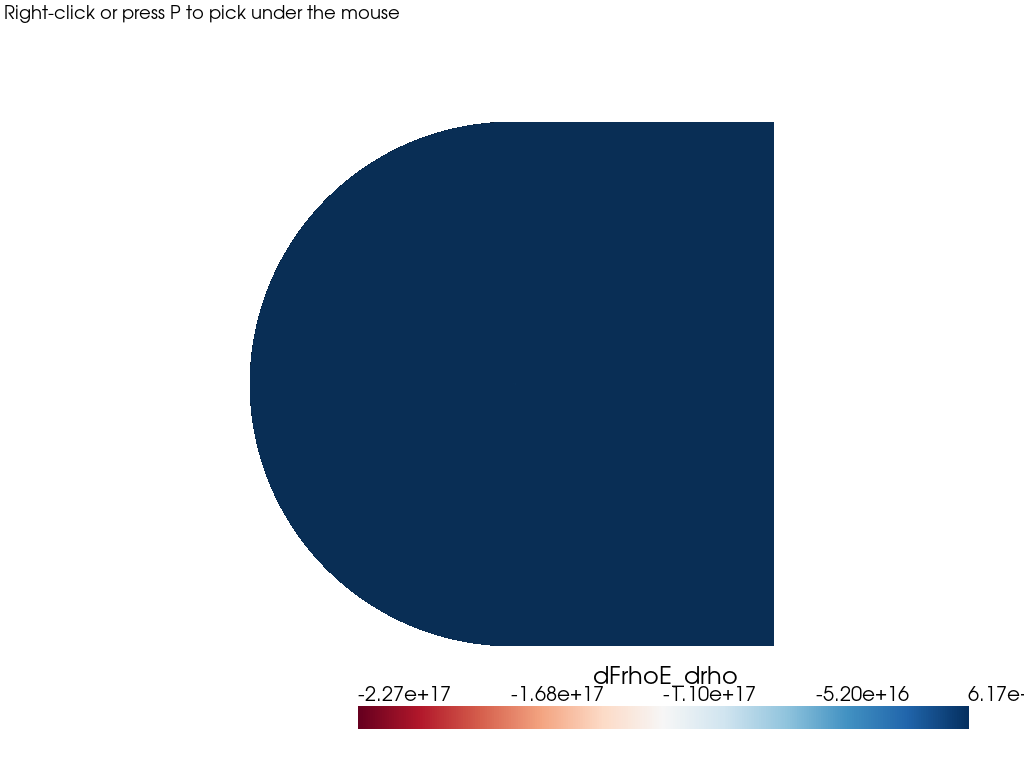

In [29]:
# ── Plot one field  ───────────────────────────────────────────────────────────
field = 'dFrhoE_drho'

def print_pick(point):
    # finds nearest point and prints its value
    pid = block.find_closest_point(point)
    err = block.point_data[field][pid]
    xy  = block.points[pid, :2]
    print(f"Node {pid}  x={xy[0]:.4f}  y={xy[1]:.4f}  val={err:.4e}")

pl = pv.Plotter(notebook = True)
pl.add_mesh(block, scalars=field, cmap='RdBu', show_edges=False, edge_color='grey',  opacity=0.99, pickable = True,
            # clim = [-0.005,0.005],
            scalar_bar_args= {
                'title_font_size': 24,   
                'label_font_size': 20,
            })
# pl.add_scalar_bar(title='dF_rho / d(rho*u)')
pl.view_xy()
pl.enable_point_picking(callback=print_pick, show_message=True,
                        font_size=10, color='black', point_size=10)
pl.show() 
# pl.save_graphic(f"Re{Re}_M{Mach}_{field}.svg")


In [30]:
# plot in log scale
# ── choose transform ──────────────────────────────────────────────────────────
eps   = 1e-16                                        # prevent log(0)
field_data = block[field]

# Option B — signed log10  (keeps sign, good for Jacobian components)
log_data  = np.sign(field_data) * np.log10(np.abs(field_data) + eps)
log_field = field + '_log10signed'

block.point_data[log_field] = log_data

# ── pick callback (reads back transformed value) ──────────────────────────────
def print_pick(point):
    pid     = block.find_closest_point(point)
    log_val = block.point_data[log_field][pid]
    raw_val = block.point_data[field][pid]       # original value for reference
    xy      = block.points[pid, :2]
    print(f"Node {pid}  x={xy[0]:.4f}  y={xy[1]:.4f}  "
          f"log10={log_val:.3f}  raw={raw_val:.4e}")

# ── plot ──────────────────────────────────────────────────────────────────────
pl = pv.Plotter(notebook=False)
pl.add_mesh(block, scalars=log_field, cmap='RdBu',
            show_edges=False, edge_color='grey', opacity=0.99,
            pickable=True,
            # clim=[-7, -6],                            # adjust: log10 range
            scalar_bar_args={
                'title':           f'{field}  [log₁₀]',
                'title_font_size': 24,
                'label_font_size': 20,
            })
pl.view_xy()
pl.camera.zoom(50) # >1 zooms in, <1 zooms out — tune to taste
pl.camera.SetFocalPoint(0.1, 0, 0)   # shift focus in +x (adjust value to taste)
pl.enable_point_picking(callback=print_pick, show_message=True,
                        font_size=10, color='black', point_size=10)
pl.show()
# pl.save_graphic(f"Re{Re}_M{Mach}_{log_field}.svg")

In [21]:
# plot multiple fields

for r in range(5):
    for c in range(5):
        field_name = f'dF{row_names[r]}_d{col_names[c]}'
        pl = pv.Plotter()
        pl.add_mesh(block, scalars=field_name, cmap='RdBu', show_edges=False, edge_color='grey', opacity=0.99,
                    scalar_bar_args= {
                        'title_font_size': 24,   
                        'label_font_size': 20,
                    })
        # pl.add_scalar_bar(title='dF_rho / d(rho*u)')
        pl.camera.zoom(50) # >1 zooms in, <1 zooms out — tune to taste
        pl.camera.SetFocalPoint(0.1, 0, 0)   # shift focus in +x (adjust value to taste)
        pl.view_xy()
        pl.camera.zoom(50) # >1 zooms in, <1 zooms out — tune to taste
        pl.camera.SetFocalPoint(0.1, 0, 0)   # shift focus in +x (adjust value to taste)
        # pl.show()
        pl.save_graphic(f"Re{Re}_M{Mach}_{field_name}.svg")
        pl.save_graphic(f"OAT15_M{Mach}_{field_name}.svg")

Plot un of each cell on the mesh to compare with the pattern of drho_drho

- Upstream stagnation (x≈-0.5, y=0)  →  uₙ ≈ 0   (flow decelerates, hits wall)
- Cylinder equator    (x=0,  |y|=0.5) →  uₙ large (flow accelerates around sides)
- Far field upstream                  →  uₙ ≈ U∞·nₓ_avg  (uniform inflow)
- Wake centreline                     →  uₙ small then recovers downstream


In [ ]:
# try to plot un of each cell on the mesh to compare with the pattern of drho_drho

# ── Normal velocity field on mesh ─────────────────────────────────────────────
# uₙ at each node = face-area-weighted average of u·n over all connected faces

N   = U_list.shape[0]
rho = U_list[:, 0]
u   = U_list[:, 1] / rho
v   = U_list[:, 2] / rho
w   = U_list[:, 3] / rho

un_sum    = np.zeros(N)
area_sum  = np.zeros(N)   # accumulate total face area per node for weighting

# Interior faces
for row in fortfile:
    i    = int(row[0]) - 1
    j    = int(row[1]) - 1
    A_ij = np.array([float(row[2]), float(row[3]), float(row[4])])
    Area = np.linalg.norm(A_ij)
    if Area < 1e-14:
        continue
    n_ij = A_ij / Area

    un_i = u[i]*n_ij[0] + v[i]*n_ij[1] + w[i]*n_ij[2]
    un_j = u[j]*n_ij[0] + v[j]*n_ij[1] + w[j]*n_ij[2]

    un_sum[i]   += un_i * Area
    un_sum[j]   += un_j * Area
    area_sum[i] += Area
    area_sum[j] += Area

# Boundary faces
for row in boundary_list:
    i    = int(row[0]) - 1
    A_bc = np.array([float(row[1]), float(row[2]), float(row[3])])
    Area = np.linalg.norm(A_bc)
    if Area < 1e-14:
        continue
    n_bc = A_bc / Area

    un_i = u[i]*n_bc[0] + v[i]*n_bc[1] + w[i]*n_bc[2]
    un_sum[i]   += un_i * Area
    area_sum[i] += Area

# Area-weighted average uₙ per node
un_node = un_sum / np.maximum(area_sum, 1e-14)

# ── Plot ──────────────────────────────────────────────────────────────────────
block.point_data['un'] = un_node

lim = np.abs(un_node).max()
pl  = pv.Plotter()
pl.add_mesh(block.copy(), scalars='un', cmap='RdBu',
            clim=[-lim, lim], show_edges=False)
# pl.add_scalar_bar(title='uₙ  (area-weighted avg normal velocity)')
pl.view_xy()
pl.show()

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x230b5f2ad50_50&reconnect=auto" class="pyvi…

 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS Error => error: Uncaught SyntaxError: Identifier 'x' has already been declared
 JS 

In [34]:
# ── Absolute face-normal sum per node ────────────────────────────────────────
nx_abs   = np.zeros(N)
ny_abs   = np.zeros(N)
area_sum = np.zeros(N)

# Interior faces
for row in fortfile:
    i    = int(row[0]) - 1
    j    = int(row[1]) - 1
    A_ij = np.array([float(row[2]), float(row[3]), float(row[4])])
    Area = np.linalg.norm(A_ij)
    if Area < 1e-14:
        continue
    n_ij = A_ij / Area

    nx_abs[i]   += abs(n_ij[0]) * Area
    nx_abs[j]   += abs(n_ij[0]) * Area
    ny_abs[i]   += abs(n_ij[1]) * Area
    ny_abs[j]   += abs(n_ij[1]) * Area
    area_sum[i] += Area
    area_sum[j] += Area

# Boundary faces
for row in boundary_list:
    i    = int(row[0]) - 1
    A_bc = np.array([float(row[1]), float(row[2]), float(row[3])])
    Area = np.linalg.norm(A_bc)
    if Area < 1e-14:
        continue
    n_bc = A_bc / Area

    nx_abs[i]   += abs(n_bc[0]) * Area
    ny_abs[i]   += abs(n_bc[1]) * Area
    area_sum[i] += Area

# Normalise by total face area per node → dimensionless [0, 1]
denom  = np.maximum(area_sum, 1e-14)
nx_abs = nx_abs / denom
ny_abs = ny_abs / denom

block.point_data['nx_abs'] = nx_abs
block.point_data['ny_abs'] = ny_abs

# ── Plot ──────────────────────────────────────────────────────────────────────
for scalar, title in [('nx_abs', 'Σ|nₓ|·A / ΣA  — x-facing dominance'),
                      ('ny_abs', 'Σ|n_y|·A / ΣA  — y-facing dominance')]:
    pl = pv.Plotter()
    pl.add_mesh(block.copy(), scalars=scalar, cmap='RdBu',
                clim=[0, 1], show_edges=False)
    pl.add_scalar_bar(title=title)
    pl.view_xy()
    pl.show()

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2321633cf50_51&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2322534d810_52&reconnect=auto" class="pyvi…

Noise and scalling issues observed in the flux jacobians 

for noise issue --> apply gaussian filter on the mesh

for scaling issues --> by non dimensionisation

In [35]:
# scaled by reference state
gamma = 1.4
rho_inf = U_list[:, 0].mean()           # far field density by taking the mean of rho in U_list
c_inf   = np.sqrt(gamma * P_in / rho_inf)   # speed of sound

# reference scale for each variable
U_ref = np.array([
    rho_inf,             # rho
    rho_inf * u_in,     # rho*u
    rho_inf * u_in,     # rho*v
    rho_inf * u_in,     # rho*w
    rho_inf * c_inf**2   # rho*E
])

# scale Jacobian block (r,c) by U_ref[c] / U_ref[r]
diag_blocks_scaled = diag_blocks.copy()
for r in range(5):
    for c in range(5):
        diag_blocks_scaled[:, r, c] *= U_ref[c] / U_ref[r]

In [36]:
# ── Attach scaled diagonal blocks to mesh ─────────────────────────────────────
row_names = col_names = ['rho', 'rhou', 'rhov', 'rhow', 'rhoE']

for r in range(5):
    for c in range(5):
        field_name = f'dF{row_names[r]}_d{col_names[c]}_scaled'
        block.point_data[field_name] = diag_blocks_scaled[:, r, c]

print(f"Attached 25 scaled Jacobian fields")

# ── Plot helper ───────────────────────────────────────────────────────────────
def plot_field(block, scalar, cmap='RdBu', pct=98, title=None):
    data  = block.point_data[scalar]
    limit = np.percentile(np.abs(data), pct)
    pl = pv.Plotter()
    pl.add_mesh(block.copy(), scalars=scalar, cmap=cmap,
                clim=[-limit, limit], show_edges=False, opacity=0.99)
    pl.add_scalar_bar(title=title or scalar)
    pl.view_xy()
    pl.show()

# ── Plot all 25 entries ───────────────────────────────────────────────────────
scalar = f'dFrhov_drho_scaled'
plot_field(block, scalar, cmap='RdBu', pct=98)

Attached 25 scaled Jacobian fields


Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2321633ce10_53&reconnect=auto" class="pyvi…

In [37]:
# ── Plot all 25 entries ───────────────────────────────────────────────────────
for r in range(5):
    for c in range(5):
        scalar = f'dF{row_names[r]}_d{col_names[c]}_scaled'
        title  = f'∂R_{row_names[r]} / ∂{col_names[c]}  (scaled)'
        plot_field(block, scalar, cmap='RdBu', pct=98, title=title)

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2322534e0d0_54&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2322534e990_55&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2322534f250_56&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2322534fb10_57&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x2323f540410_58&reconnect=auto" class="pyvi…

...

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x232cd1ed090_74&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x232cd1ed950_75&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x232cd1ee210_76&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x232cd1eead0_77&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:56510/index.html?ui=P_0x232cd1ef390_78&reconnect=auto" class="pyvi…